In [ ]:
# PRELOADS
import sys
sys.dont_write_bytecode = True

import pandas            as pd
import numpy             as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import seaborn           as sns

from sklearn.metrics       import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Timeserie-related import(s) was done as a joke, since this dataset is basically a timeserie

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.seasonal      import seasonal_decompose
# from statsmodels.tsa.stattools     import adfuller
# from statsmodels.tsa.arima.model   import ARIMA

## **DATASET OVERVIEW**

In [ ]:
try:
    # Direct import for those who downloaded and imported the CSV here
    tetoris = pd.read_csv("Tetuan City power consumption.csv")
except FileNotFoundError:
    # In case you don't, the datast will be imported via the provided code in the dataset:
    # https://archive-beta.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city
    try:
        from ucimlrepo import fetch_ucirepo
    except ModuleNotFoundError:
        # And just in case you don't have that module
        !pip install ucimlrepo
        from ucimlrepo import fetch_ucirepo

    # fetch dataset
    power_consumption_of_tetouan = fetch_ucirepo(id=849)

    tetoris = power_consumption_of_tetouan.data.original.copy()

# Basic overview
display(tetoris.head())
display(tetoris.info())
display(tetoris.describe())
display(tetoris.isnull().sum())

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


None

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


,0
DateTime,0
Temperature,0
Humidity,0
Wind Speed,0
general diffuse flows,0
diffuse flows,0
Zone 1 Power Consumption,0
Zone 2 Power Consumption,0
Zone 3 Power Consumption,0


In [ ]:
# Time indexing
tetoris['DateTime'] = pd.to_datetime(tetoris['DateTime'], format='mixed')
tetoris = tetoris.set_index('DateTime')

display(tetoris.head())

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


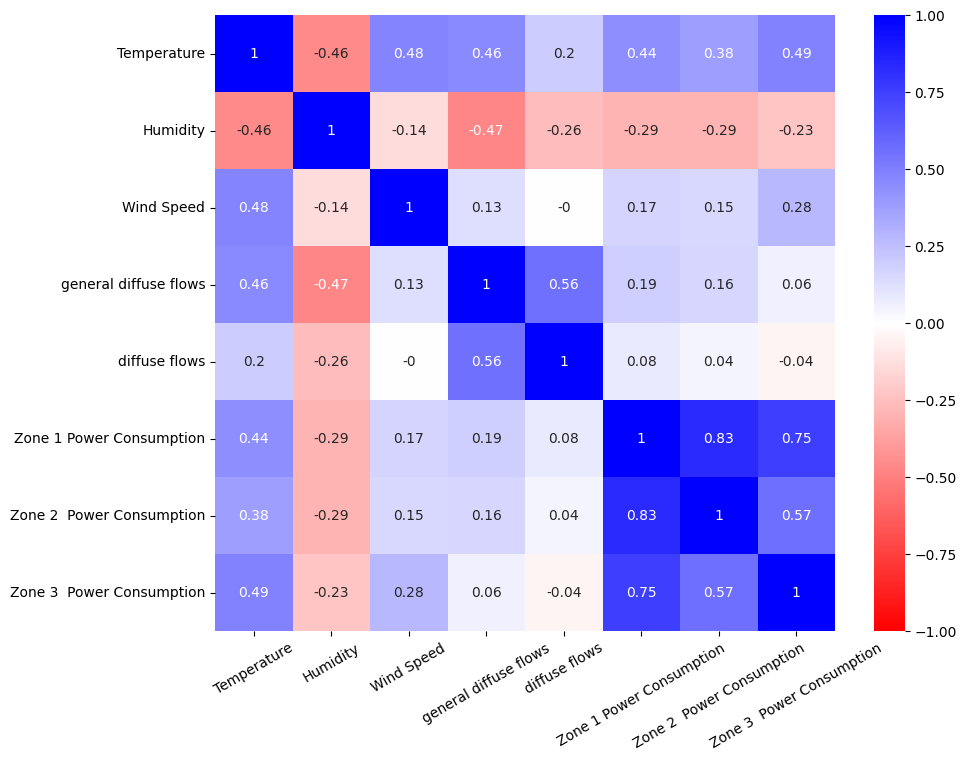

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(tetoris.corr().round(2), cmap="bwr_r", annot=True, vmax=1, vmin=-1)
plt.xticks(rotation=30)
plt.show()

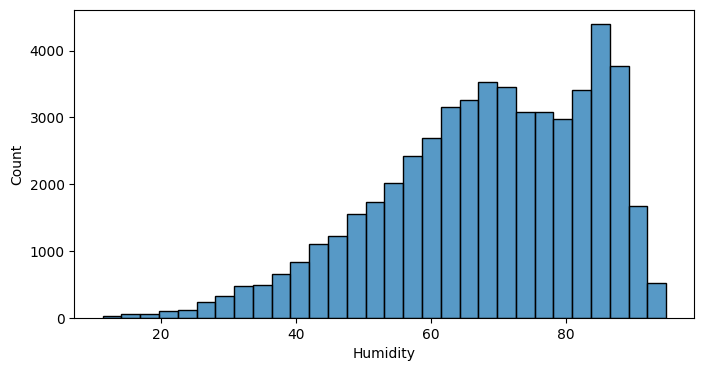

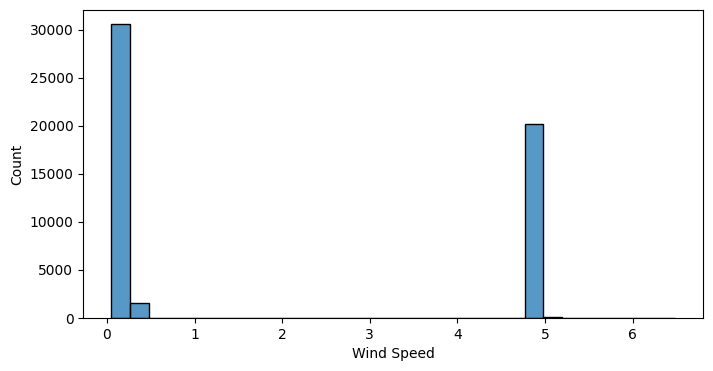

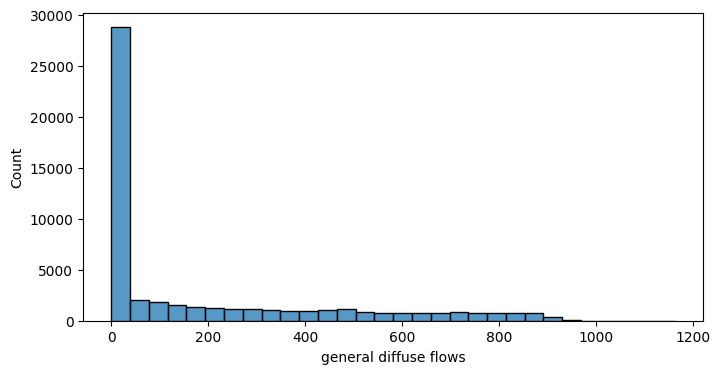

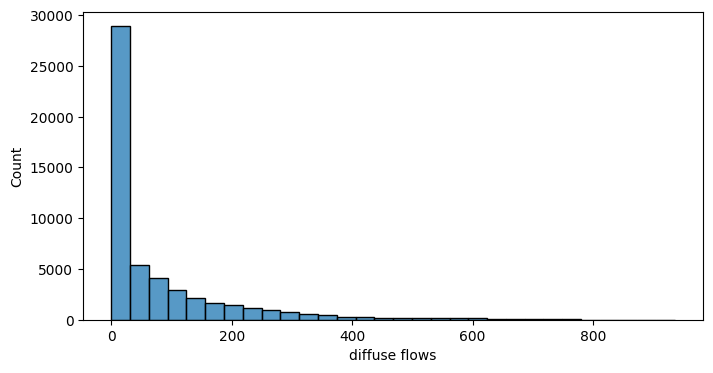

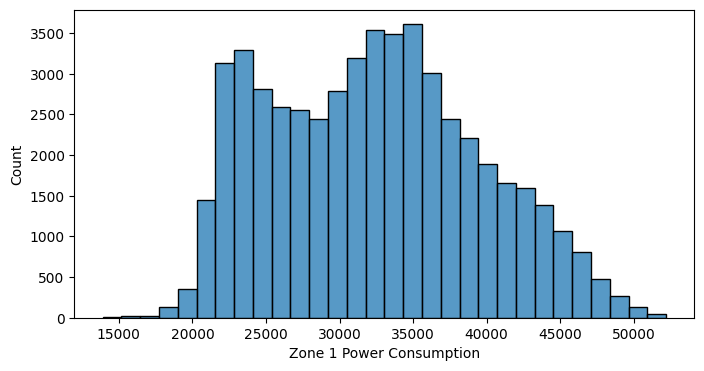

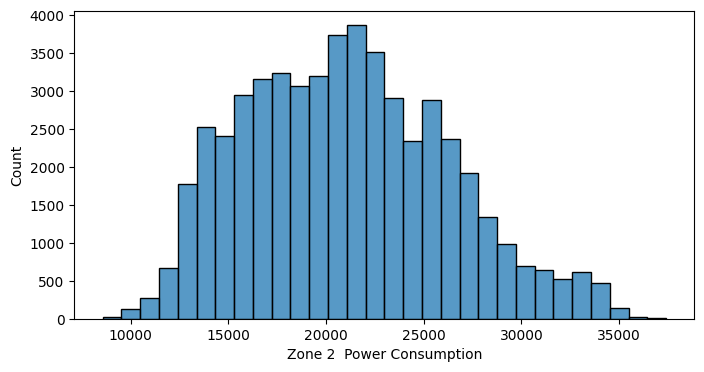

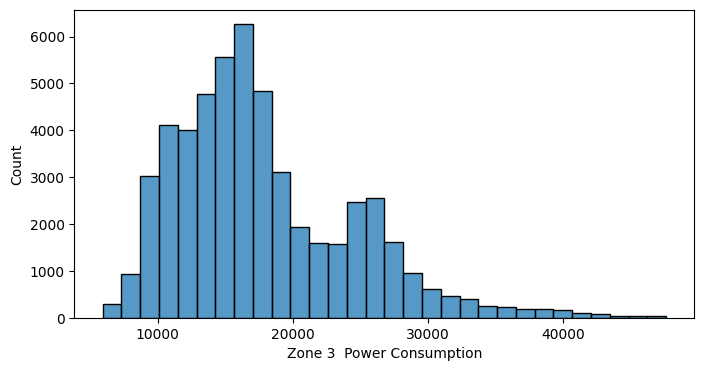

In [ ]:
# Histogram
for c in tetoris.columns[1:]:
  plt.figure(figsize=(8,4))
  sns.histplot(data=tetoris, x=c, bins=30)
  plt.show()

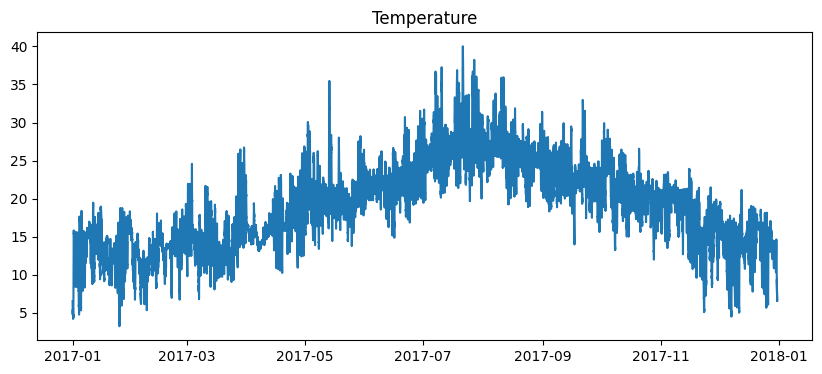

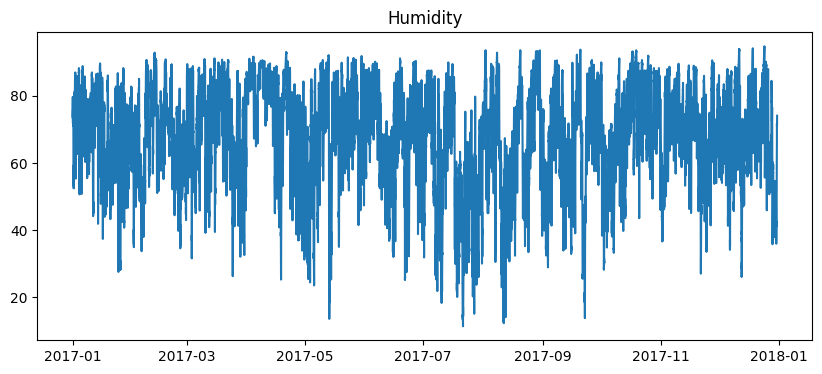

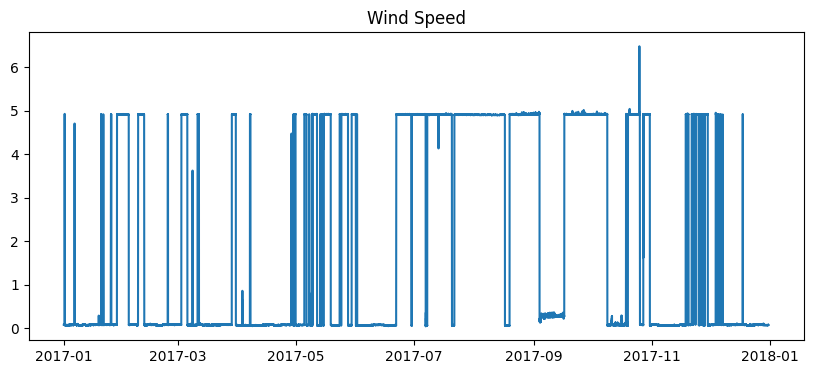

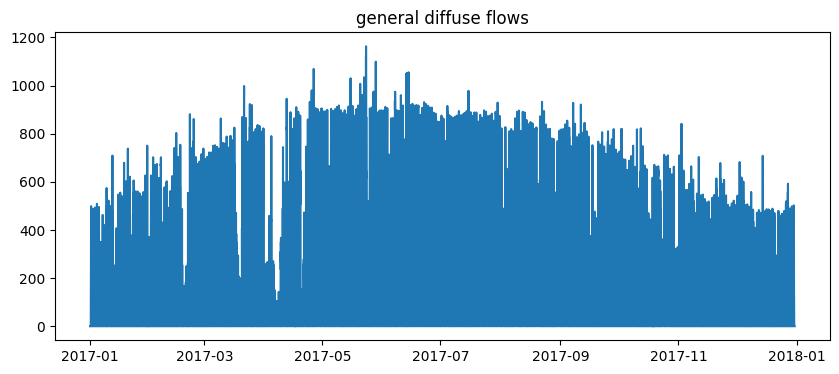

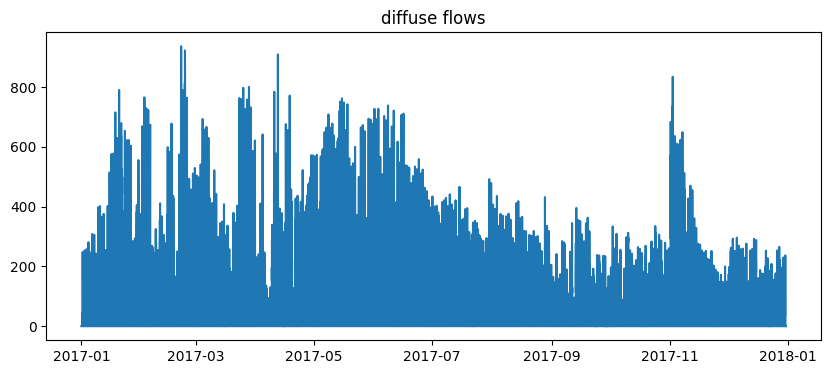

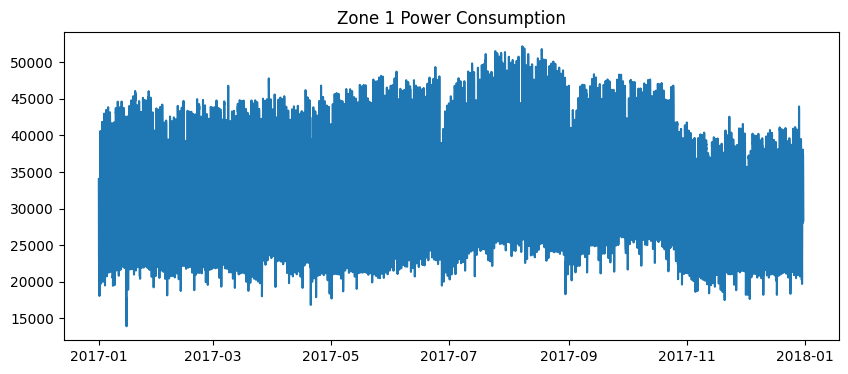

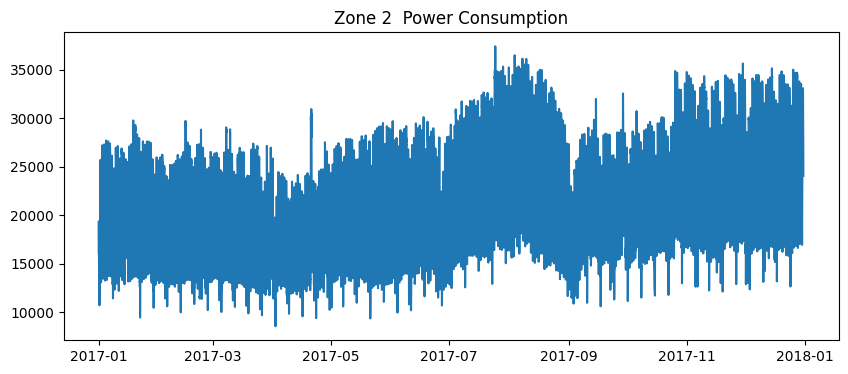

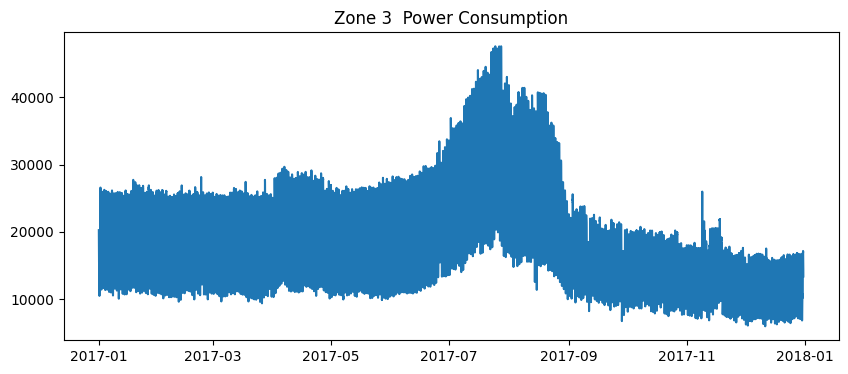

In [ ]:
# Data plotting
for c in tetoris.columns:
  plt.figure(figsize=(10,4))
  plt.plot(tetoris[c])
  plt.title(c)
  plt.show()

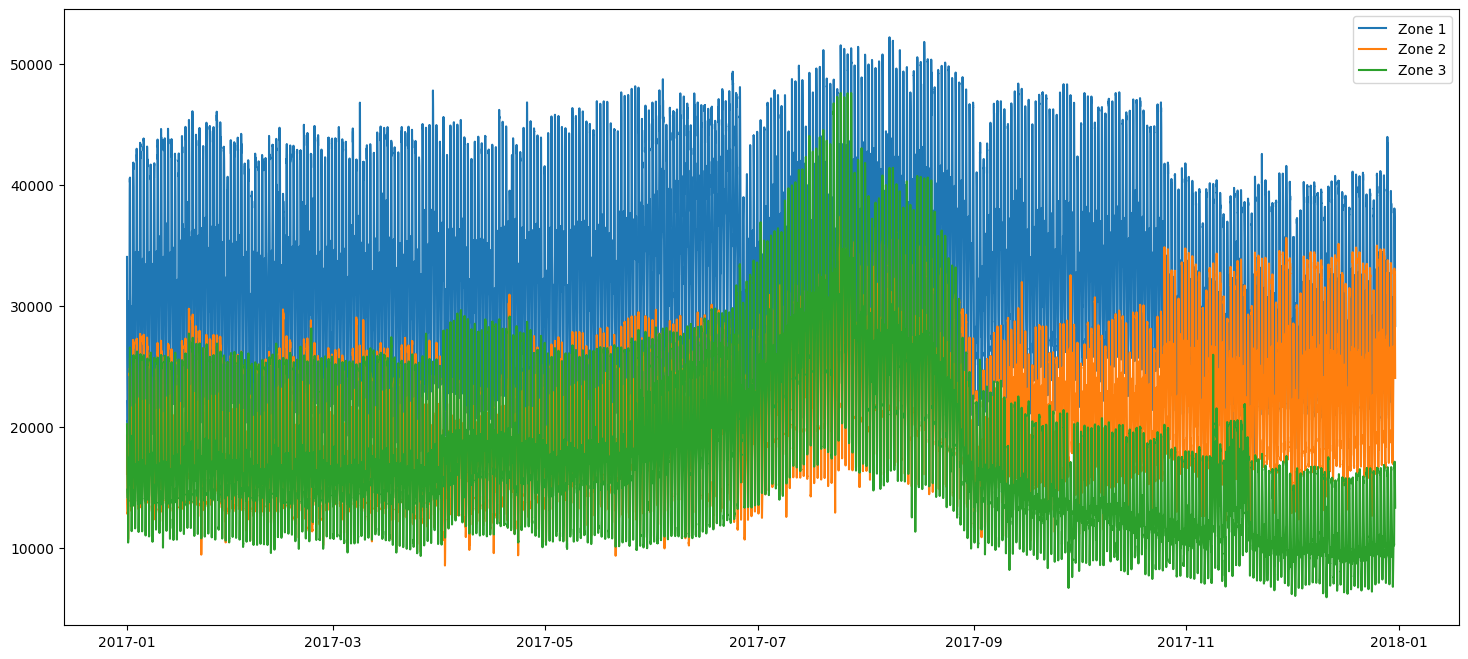

In [ ]:
# Zone overlay
zones = tetoris.columns[-3:]
plt.figure(figsize=(18,8))
plt.plot(tetoris.index, tetoris[zones[0]], label="Zone 1")
plt.plot(tetoris.index, tetoris[zones[1]], label="Zone 2")
plt.plot(tetoris.index, tetoris[zones[2]], label="Zone 3")
plt.legend()
plt.show()

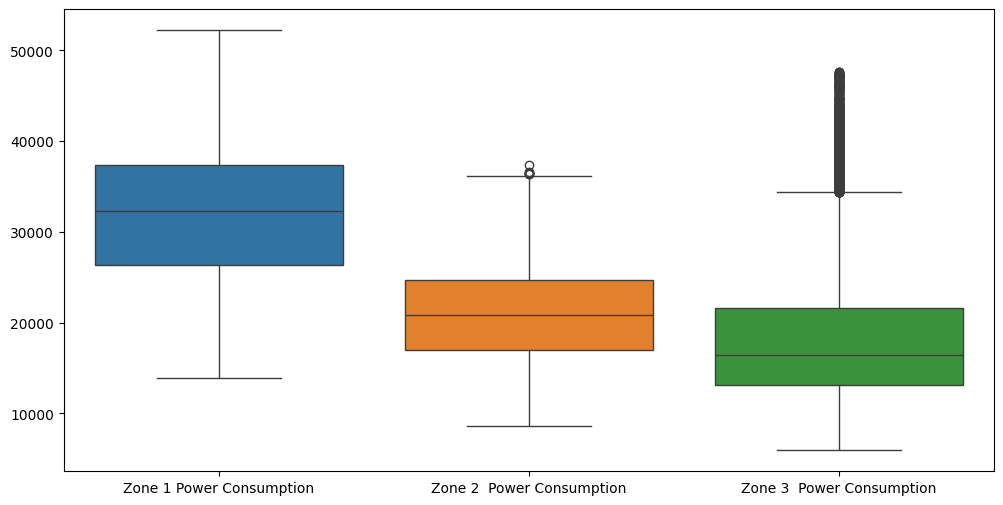

In [ ]:
# Boxplot of power consumptions
plt.figure(figsize=(12,6))
sns.boxplot(data=tetoris[tetoris.columns[-3:]])
plt.show()

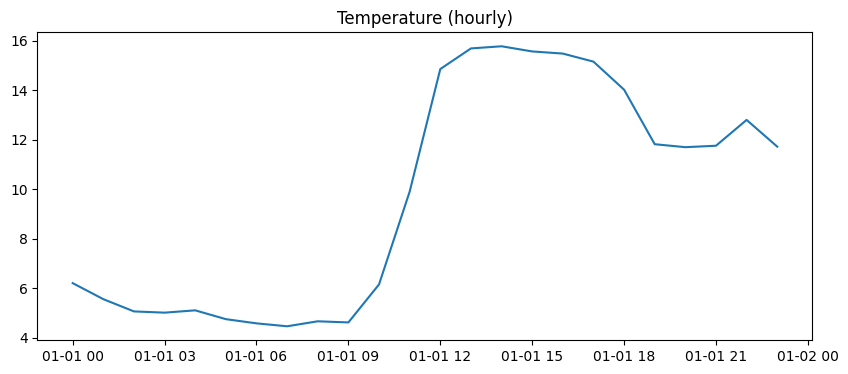

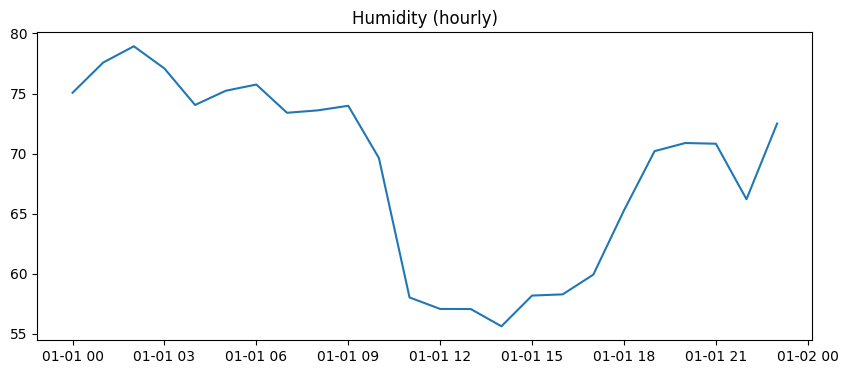

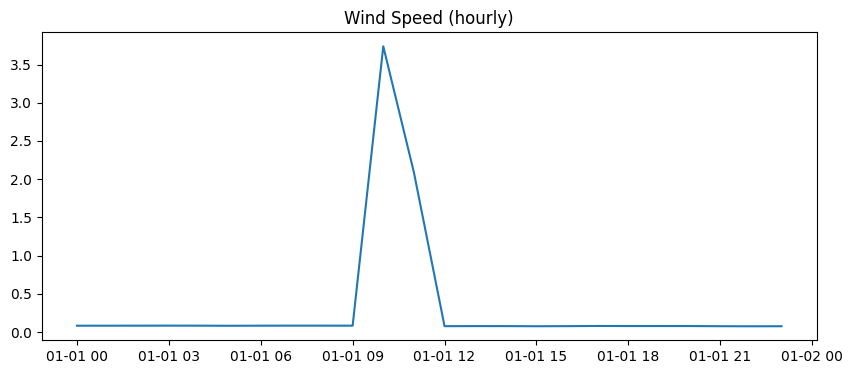

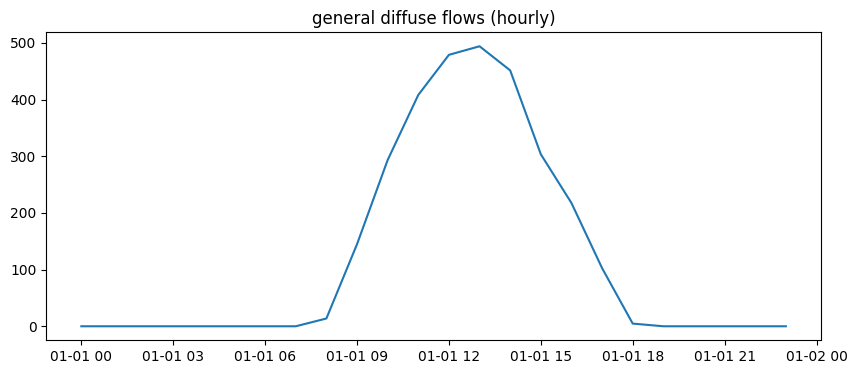

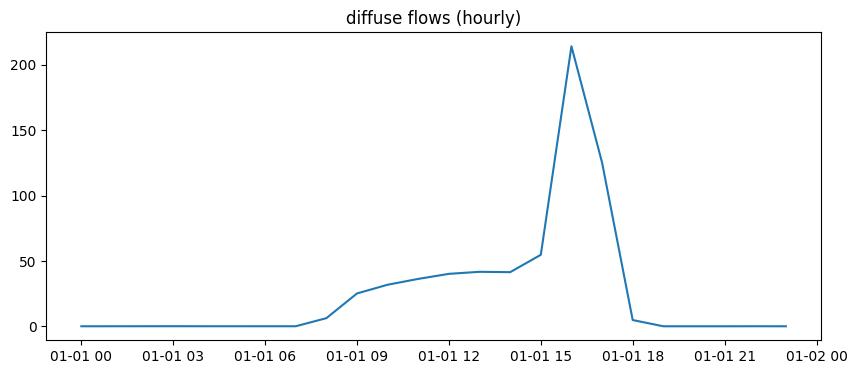

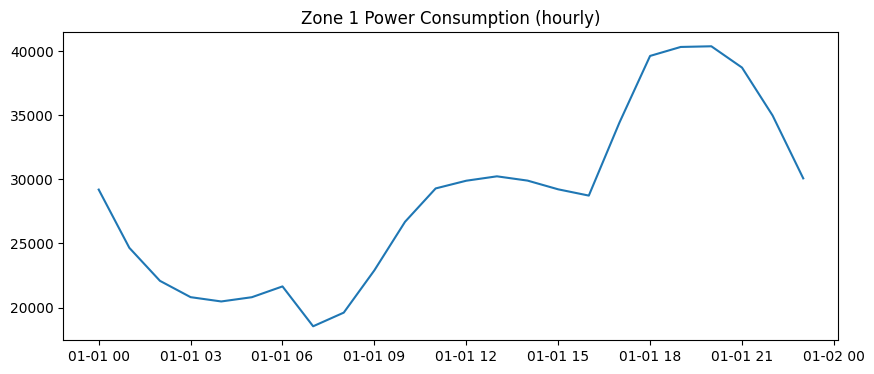

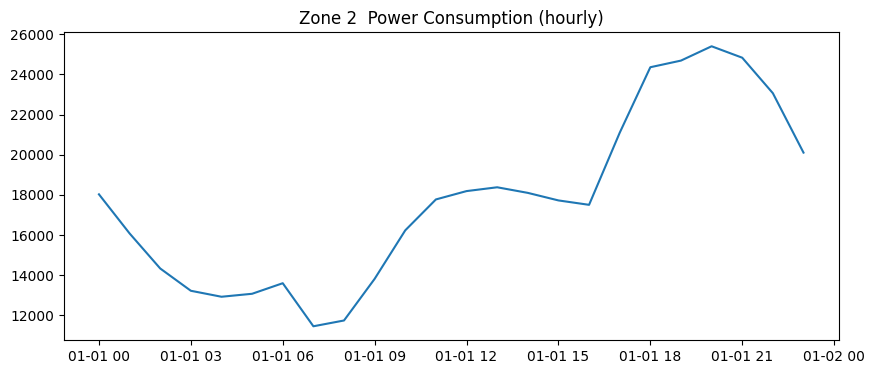

In [ ]:
# Line plots: Indicators by hourly in a single day (or first day from the dataset)
for c in h_tetoris.columns:
  plt.figure(figsize=(10,4))
  plt.plot(h_tetoris.index[:24], h_tetoris[c][:24])
  #plt.plot(h_tetoris.index, h_tetoris[c])
  plt.title(c + " (hourly)")
  plt.show()